In [1]:
# My First Kaggle Notebook
# Raj Gajare | Prime 2.0

import pandas as pd
import matplotlib.pyplot as plt

# Load Titanic train data (contains 'Survived' column)
df = pd.read_csv('/kaggle/input/datasets/azeembootwala/titanic/test_data.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Info:")
print(df.info())

print("\nKitne log survive kiye?")
print(df['Survived'].value_counts())

Shape: (100, 17)

First 5 rows:
   Unnamed: 0  PassengerId  Survived  Sex     Age      Fare  Pclass_1  \
0         791          792         0    1  0.2000  0.050749         0   
1         792          793         0    0  0.3500  0.135753         0   
2         793          794         0    1  0.3500  0.059914         1   
3         794          795         0    1  0.3125  0.015412         0   
4         795          796         0    1  0.4875  0.025374         0   

   Pclass_2  Pclass_3  Family_size  Title_1  Title_2  Title_3  Title_4  Emb_1  \
0         1         0          0.0        1        0        0        0      0   
1         0         1          1.0        0        0        0        1      0   
2         0         0          0.0        1        0        0        0      1   
3         0         1          0.0        1        0        0        0      0   
4         1         0          0.0        1        0        0        0      0   

   Emb_2  Emb_3  
0      0      1  
1     

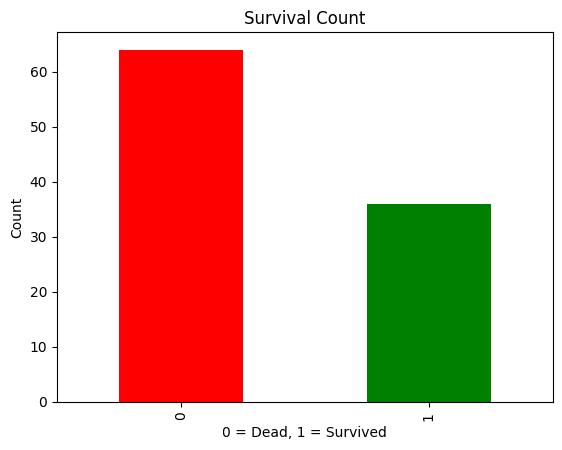

In [2]:
# Simple visualization
df['Survived'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Survival Count')
plt.xlabel('0 = Dead, 1 = Survived')
plt.ylabel('Count')
plt.show()


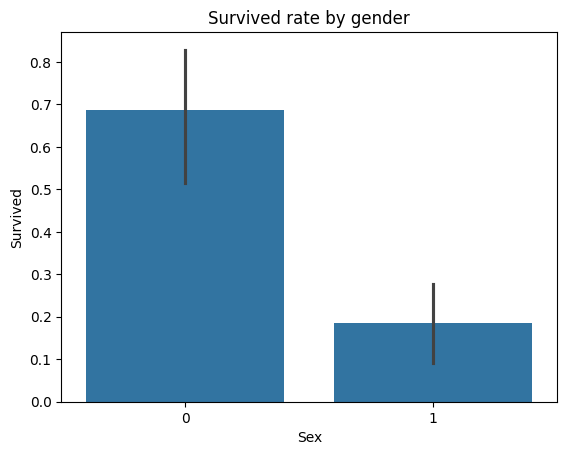

In [3]:
import seaborn as sns
sns.barplot(x='Sex', y="Survived",data=df)
plt.title('Survived rate by gender')
plt.show()

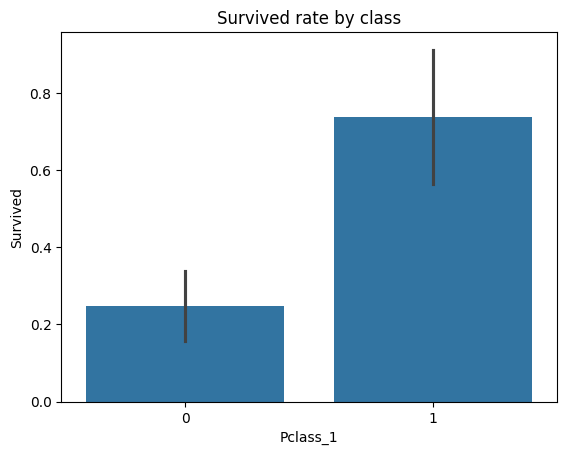

In [4]:
sns.barplot(x='Pclass_1',y='Survived',data=df)
plt.title('Survived rate by class')
plt.show()

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0     0
PassengerId    0
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64


In [6]:
# Set & Dict use karke Titanic Analysis
# Unique values in each column
print("Unique values in each column:")
for col in df.columns:
    print(f"{col}: {len(set(df[col]))} unique values")
    
# Passenger class frequency using dict
pclass_freq = df['Pclass_1'].value_counts().to_dict()
print("\nPassenger Class Distribution:")
for cls, count in pclass_freq.items():
    print(f"  Class {cls}: {count} passengers")

# Survival rate per class
survival_dict = df.groupby('Pclass_1')['Survived'].mean().to_dict()
print("\nSurvival Rate by Class:")
for cls, rate in survival_dict.items():
    print(f"  Class {cls}: {rate:.2%}")

Unique values in each column:
Unnamed: 0: 100 unique values
PassengerId: 100 unique values
Survived: 2 unique values
Sex: 2 unique values
Age: 46 unique values
Fare: 66 unique values
Pclass_1: 2 unique values
Pclass_2: 2 unique values
Pclass_3: 2 unique values
Family_size: 7 unique values
Title_1: 2 unique values
Title_2: 2 unique values
Title_3: 2 unique values
Title_4: 2 unique values
Emb_1: 2 unique values
Emb_2: 2 unique values
Emb_3: 2 unique values

Passenger Class Distribution:
  Class 0: 77 passengers
  Class 1: 23 passengers

Survival Rate by Class:
  Class 0: 24.68%
  Class 1: 73.91%


In [7]:
# OOP based Data Analysis
class TitanicAnalyzer:
    def __init__(self, dataframe):
        self.df = dataframe
    
    def survival_rate(self):
        rate = self.df['Survived'].mean()
        print(f"Overall Survival Rate: {rate:.2%}")
    
    def gender_analysis(self):
        print("\nSurvival by Gender:")
        print(self.df.groupby('Sex')['Survived'].mean())
    
    def class_analysis(self):
        print("\nSurvival by Class:")
        print(self.df.groupby('Pclass_1')['Survived'].mean())

# Use karo
analyzer = TitanicAnalyzer(df)
analyzer.survival_rate()
analyzer.gender_analysis()
analyzer.class_analysis()

Overall Survival Rate: 36.00%

Survival by Gender:
Sex
0    0.685714
1    0.184615
Name: Survived, dtype: float64

Survival by Class:
Pclass_1
0    0.246753
1    0.739130
Name: Survived, dtype: float64


In [8]:
# Missing values check
print("Missing Values:")
print(df.isnull().sum())

# Age missing values fill karo
df['Age'].fillna(df['Age'].median(), inplace=True)

# Verify
print("\nAfter Cleaning:")
print(df.isnull().sum())

# Insights
print("\n=== Key Insights ===")
print(f"Total Passengers: {len(df)}")
print(f"Survival Rate: {df['Survived'].mean():.2%}")
print(f"Average Age: {df['Age'].mean():.1f} years")
print(f"Female Survival: {df[df['Sex']=='female']['Survived'].mean():.2%}")
print(f"Male Survival: {df[df['Sex']=='male']['Survived'].mean():.2%}")

Missing Values:
Unnamed: 0     0
PassengerId    0
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64

After Cleaning:
Unnamed: 0     0
PassengerId    0
Survived       0
Sex            0
Age            0
Fare           0
Pclass_1       0
Pclass_2       0
Pclass_3       0
Family_size    0
Title_1        0
Title_2        0
Title_3        0
Title_4        0
Emb_1          0
Emb_2          0
Emb_3          0
dtype: int64

=== Key Insights ===
Total Passengers: 100
Survival Rate: 36.00%
Average Age: 0.4 years
Female Survival: nan%
Male Survival: nan%


/tmp/ipykernel_17/1408854032.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
import numpy as np

# Age array banao
ages = np.array(df['Age'])

print("=== NumPy on Titanic ===")
print(f"Mean Age: {np.mean(ages):.1f}")
print(f"Max Age: {np.max(ages)}")
print(f"Min Age: {np.min(ages)}")
print(f"Std Dev: {np.std(ages):.1f}")

# Fare analysis
fares = np.array(df['Fare'])
print(f"\nMean Fare: {np.mean(fares):.2f}")
print(f"Max Fare: {np.max(fares):.2f}")

# Age groups
young = np.sum(ages < 18)
adult = np.sum((ages >= 18) & (ages < 60))
senior = np.sum(ages >= 60)

print(f"\nAge Groups:")
print(f"Children (<18): {young}")
print(f"Adults (18-60): {adult}")
print(f"Senior (60+): {senior}")

=== NumPy on Titanic ===
Mean Age: 0.4
Max Age: 0.925
Min Age: 0.0052499999999999
Std Dev: 0.2

Mean Fare: 0.05
Max Fare: 0.32

Age Groups:
Children (<18): 100
Adults (18-60): 0
Senior (60+): 0
